- # Installation

In [1]:
pip install -q baccoemu emantis astropy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 6.1 MB/s eta 0:00:00


- # Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import baccoemu
from emantis.matter_power_spectrum import NonLinearMGBoostEmulator

# Suppress warnings
warnings.filterwarnings('ignore')

- # Common Cosmological Parameters

In [3]:
# ========================================================
# Common Cosmological Parameters
# ========================================================
common_params = {
    "Omega_m": 0.315,       # Total matter density
    "Omega_b": 0.05,        # Baryon density
    "h": 0.67,              # Hubble parameter
    "n_s": 0.96,            # Scalar spectral index
    "sigma8": 0.83,         # Sigma8 normalization
    "M_nu": 0.0,            # Neutrino mass [eV]
    "w0": -1.0,             # Dark energy equation of state parameter
    "wa": 0.0,              # Running of w
    "aexp": 1.0             # Expansion factor
}

- # Model Switch: Choose $GR$ or $f(R)$

In [4]:
# ========================================================
# Model Switch: Choose GR or f(R)
# ========================================================
# Options:
#   None → GR (no MG boost applied)
#   4,5,6,7 → f(R) models (log10|fR0| = -value)
chosen_logfR0 = 5   # Example: fR0 = -1e-5. Set to None for GR.

- # Bacco Emulator - Nonlinear Matter Power Spectrum

In [5]:
# ========================================================
# Bacco Emulator - Nonlinear Matter Power Spectrum
# ========================================================
emulator = baccoemu.Matter_powerspectrum(verbose=False)
k = np.logspace(-2, np.log10(emulator.emulator['nonlinear']['k'].max()), num=200)

params_bacco = {
    "omega_cold": common_params["Omega_m"] - common_params["Omega_b"],
    "sigma8_cold": common_params["sigma8"],
    "omega_baryon": common_params["Omega_b"],
    "ns": common_params["n_s"],
    "hubble": common_params["h"],
    "neutrino_mass": common_params["M_nu"],
    "w0": common_params["w0"],
    "wa": common_params["wa"],
    "expfactor": common_params["aexp"]
}

k, Q_total = emulator.get_nonlinear_boost(k=k, cold=False, **params_bacco)
k, pk_nl_total = emulator.get_nonlinear_pk(k=k, cold=False, **params_bacco)


100% (358400 of 358400) |################| Elapsed Time: 0:00:00 Time:  0:00:00


100% (1966080 of 1966080) |##############| Elapsed Time: 0:00:00 Time:  0:00:00


100% (1966080 of 1966080) |##############| Elapsed Time: 0:00:00 Time:  0:00:00


100% (2293760 of 2293760) |##############| Elapsed Time: 0:00:00 Time:  0:00:00


100% (3000320 of 3000320) |##############| Elapsed Time: 0:00:00 Time:  0:00:00


100% (4833280 of 4833280) |##############| Elapsed Time: 0:00:00 Time:  0:00:00


- # e-MANTIS Emulator - Boost Factor for $f(R)$

In [6]:
# ========================================================
# e-MANTIS Emulator - Boost Factor for f(R)
# ========================================================
emu = NonLinearMGBoostEmulator(verbose=False)

if chosen_logfR0 is not None:
    params_emantis = {
        "Omega_m": common_params["Omega_m"],
        "Omega_b": common_params["Omega_b"],
        "h": common_params["h"],
        "n_s": common_params["n_s"],
        "sigma8_lcdm": common_params["sigma8"],
        "logfR0": chosen_logfR0
    }
    pk_boost = emu.predict_boost(params_emantis, aexp=common_params["aexp"], k=k)
    pk_fR = pk_nl_total * pk_boost
else:
    # GR case (no boost, just Bacco result)
    pk_fR = pk_nl_total

  return datetime.utcnow().replace(tzinfo=utc)



- # Plot Results

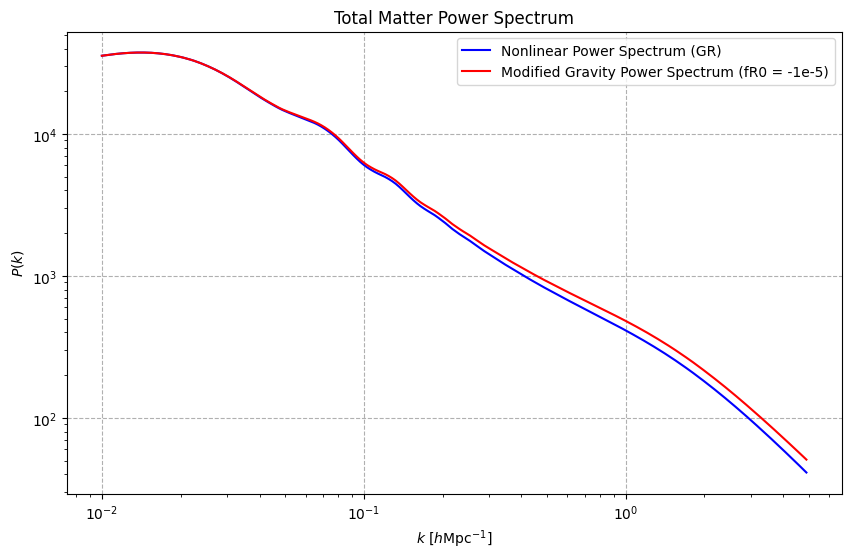

In [7]:
# ========================================================
# Plot Results
# ========================================================
plt.figure(figsize=(10, 6))
plt.loglog(k, pk_nl_total, label="Nonlinear Power Spectrum (GR)", color='blue')
if chosen_logfR0 is not None:
    plt.loglog(k, pk_fR, label=f"Modified Gravity Power Spectrum (fR0 = -1e-{chosen_logfR0})", color='red')
plt.xlabel(r'$k \ \left[h\mathrm{Mpc}^{-1}\right]$')
plt.ylabel(r'$P(k)$')
plt.legend()
plt.title("Total Matter Power Spectrum")
plt.grid(True, linestyle='--')
plt.show()